# El coste del error: dónde poner el umbral

**Facsímil 7 · Evaluar, calibrar e interpretar** — capítulo 2 (métricas clásicas: matriz de confusión y
coste del error).

La métrica que de verdad importa casi nunca es «el acierto», sino «cuánto me cuesta equivocarme». Y como
los dos tipos de error no cuestan lo mismo, el **umbral** de un clasificador es una **decisión de
negocio**, no un valor sagrado. En este cuaderno dejas de elegir el umbral «por defecto» (0,5) y lo
eliges **por dinero**: en la detección de fraude, dejar pasar un fraude cuesta mucho más que revisar una
transacción legítima de más. Pones número a cada error y encuentras el umbral que minimiza el coste
total. Sorpresa: casi nunca es 0,5.

### Qué vas a aprender
- Por qué el **acierto** es mala guía cuando una clase es rara y un error cuesta más que otro.
- A leer la **matriz de confusión** en términos de coste (falsos negativos vs falsos positivos).
- A **barrer umbrales** y dibujar la curva del coste para encontrar el óptimo.
- Que ese umbral óptimo depende de **tus** costes, y casi nunca vale 0,5.

### Cuánto cuesta
Unos 12 minutos. CPU, sin claves.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
np.random.seed(0)

# Fraude: clase rara (8%). Lo normal en estos problemas.
X, y = make_classification(n_samples=6000, weights=[0.92, 0.08], n_informative=6, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.4, random_state=0)
modelo = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
p = modelo.predict_proba(X_te)[:, 1]
print(f"{y_te.sum()} fraudes reales de {len(y_te)} transacciones de prueba ({100*y_te.mean():.0f}%).")


194 fraudes reales de 2400 transacciones de prueba (8%).


## 1. El acierto engaña con clases raras

Con un 8% de fraude, un modelo tonto que diga «nunca hay fraude» acierta el **92%**... y es completamente
inútil (no caza ni un fraude). El acierto, en problemas desbalanceados, premia ignorar la clase rara. Lo
comprobamos antes de seguir.


In [2]:
acc_tonto = 1 - y_te.mean()    # "siempre legitima"
acc_modelo = (modelo.predict(X_te) == y_te).mean()
print(f"Modelo tonto ('nunca hay fraude'): acierto {acc_tonto:.3f}  <- altisimo e INUTIL (0 fraudes cazados)")
print(f"Nuestro modelo:                    acierto {acc_modelo:.3f}")
print("El acierto, con clases raras, es una guia tramposa. Hay que mirar el COSTE de cada error.")


Modelo tonto ('nunca hay fraude'): acierto 0.919  <- altisimo e INUTIL (0 fraudes cazados)
Nuestro modelo:                    acierto 0.965
El acierto, con clases raras, es una guia tramposa. Hay que mirar el COSTE de cada error.


## 2. Ponerle precio a cada error

Hay dos tipos de error, y no cuestan lo mismo:

- **Fraude no detectado** (falso negativo): se pierde el importe. Caro. Digamos **100 €**.
- **Legítima bloqueada** (falso positivo): un cliente molesto, una revisión manual. Barato: **5 €**.

Con esos precios, recorremos todos los umbrales posibles y calculamos el coste total de cada uno. El
coste, no el acierto, es nuestra brújula.


In [3]:
COSTE_FN, COSTE_FP = 100, 5
umbrales = np.linspace(0.01, 0.99, 99)
costes = []
for u in umbrales:
    pred = (p >= u).astype(int)
    fn = ((pred == 0) & (y_te == 1)).sum()
    fp = ((pred == 1) & (y_te == 0)).sum()
    costes.append(fn*COSTE_FN + fp*COSTE_FP)
costes = np.array(costes)
u_opt = umbrales[int(np.argmin(costes))]
coste_05 = costes[np.argmin(np.abs(umbrales-0.5))]
print(f"Umbral por defecto (0.50): coste {coste_05:>6} EUR")
print(f"Umbral optimo ({u_opt:.2f}):       coste {costes.min():>6} EUR")
print(f"Ahorro por mover el umbral: {coste_05 - costes.min()} EUR")


Umbral por defecto (0.50): coste   7735 EUR
Umbral optimo (0.07):       coste   4780 EUR
Ahorro por mover el umbral: 2955 EUR


## 3. La curva del coste

Cada punto es un umbral; el eje vertical, lo que te cuesta. El mínimo de esta curva es tu decisión
óptima. Fíjate en que está **lejos de 0,5**: como dejar pasar un fraude es 20 veces más caro que una
falsa alarma, conviene ser desconfiado y bajar el listón para no perder fraudes.


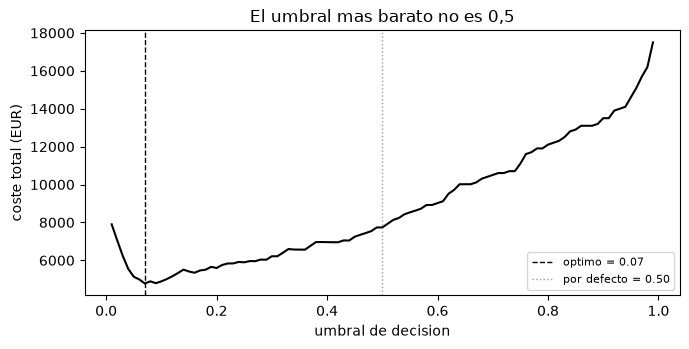

In [4]:
plt.figure(figsize=(7, 3.6))
plt.plot(umbrales, costes, color="black")
plt.axvline(u_opt, ls="--", color="black", lw=1, label=f"optimo = {u_opt:.2f}")
plt.axvline(0.5, ls=":", color="#9c9c9c", lw=1, label="por defecto = 0.50")
plt.xlabel("umbral de decision"); plt.ylabel("coste total (EUR)")
plt.title("El umbral mas barato no es 0,5"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4. Experimento: el umbral óptimo se mueve con los costes

El umbral óptimo no es una propiedad del modelo: depende de **cuánto cuesta cada error**, que es una
decisión de negocio. Si el fraude se vuelve más caro, conviene ser aún más desconfiado (umbral más bajo);
si las falsas alarmas se vuelven carísimas, al revés. Lo medimos variando el coste del fraude no
detectado.


In [5]:
print("coste de un fraude | umbral optimo | falsas alarmas en el optimo")
for coste_fn in [20, 100, 500]:
    cs = [((p>=u).astype(int)==0).__and__(y_te==1).sum()*coste_fn +
          ((p>=u).astype(int)==1).__and__(y_te==0).sum()*COSTE_FP for u in umbrales]
    u_o = umbrales[int(np.argmin(cs))]
    fp_o = (((p>=u_o).astype(int)==1) & (y_te==0)).sum()
    print(f"      {coste_fn:>4} EUR      |     {u_o:.2f}     |        {fp_o:>3}")
print("\nCuanto mas caro el fraude, mas baja el umbral (mas desconfiado), a costa de mas falsas alarmas.")


coste de un fraude | umbral optimo | falsas alarmas en el optimo
        20 EUR      |     0.29     |         26
       100 EUR      |     0.07     |        416
       500 EUR      |     0.01     |        1400

Cuanto mas caro el fraude, mas baja el umbral (mas desconfiado), a costa de mas falsas alarmas.


## 5. Pruébalo tú

1. **Iguala los costes** (`COSTE_FN = COSTE_FP`). ¿Se acerca el óptimo a 0,5? Cuando los errores cuestan
   lo mismo, el umbral neutro recupera su sentido.
2. **Cuenta las falsas alarmas** en el óptimo: ¿cuántos clientes legítimos molestas para ahorrar esos
   euros? Ese es el otro lado de la balanza que un número no decide por ti.
3. **Combina con calibración:** este cálculo se fía de las probabilidades. Si están mal calibradas
   (cuaderno anterior), el umbral óptimo que calcules estará sesgado. Recalibra y repite.
4. **Curva precision-recall:** dibújala y localiza dónde cae tu umbral óptimo. Es otra forma de ver el
   mismo compromiso.


## 6. Errores comunes

- **Usar el acierto con clases raras.** Premia ignorar la clase rara. Mira el coste o métricas como
  recall y precisión por clase.
- **Quedarse con el umbral 0,5.** Es solo el centro de la escala, no tiene nada de especial. Elígelo por
  coste.
- **Olvidar que el umbral depende del negocio.** No hay un umbral «correcto» universal: depende de cuánto
  cuesta cada error en *tu* caso.
- **Fiarte de probabilidades mal calibradas** para elegir el umbral. Calibra primero.


## 7. Qué te llevas

- El **acierto** es mala guía cuando una clase es rara y un error cuesta más que otro: con un 8% de
  fraude, decir «nunca hay fraude» acierta el 92% y es inútil.
- La métrica honesta es el **coste esperado**; el **umbral** es la palanca para minimizarlo, y casi nunca
  vale 0,5.
- Ese umbral **se mueve con los costes**: elegirlo es una decisión de negocio informada por datos, no un
  ajuste técnico.

**Para seguir:** esto se apoya en que las probabilidades estén calibradas (cuaderno anterior); el
facsímil 9 lleva estas decisiones al terreno del riesgo y la gobernanza.


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*